In [2]:
import numpy as np
import pycbc
import matplotlib.pyplot as plt
from pycbc.psd import aLIGOAPlusDesignSensitivityT1800042
from pycbc.waveform import get_fd_waveform, get_waveform_filter_length_in_time as chirplen
from pycbc.filter.matchedfilter import overlap, match
from tqdm import tqdm
from pycbc.conversions import mass1_from_tau0_tau3, mass2_from_tau0_tau3, tau0_from_mass1_mass2, tau3_from_mass1_mass2
from pycbc.conversions import eta_from_mass1_mass2
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
from pycbc.types.frequencyseries import FrequencySeries
from scipy.interpolate import griddata
from scipy.interpolate import griddata
import matplotlib.colors as mcolors
import pandas as pd
from scipy.stats import qmc
from sklearn.neighbors import BallTree
from scipy.stats.qmc import Sobol
from metric_utils_3d import get_wf, m1_m2f_theta03, theta03,theta3s_m_s, convert_to_chi1chi2, metric_3d, velocity_to_frequency, f_schwarzchild_isco
from utils import metric_2d
from pycbc.psd import from_txt

We want to construct an ellipse defined by a metric $g$:

$$
x^\top g\,x \le 1
$$

---

**1. Diagonalize the metric matrix:**

$$
g = V \Lambda V^\top, \quad \text{where} \quad \Lambda = \mathrm{diag}(\lambda_1, \lambda_2)
$$

---

**2. Change coordinates:**

Let:
$$
y = V^\top x
$$

Then the inequality becomes:

$$
\lambda_1 y_1^2 + \lambda_2 y_2^2 \le 1
$$

This is the standard form of an ellipse:

$$
\frac{y_1^2}{1/\lambda_1} + \frac{y_2^2}{1/\lambda_2} \le 1
$$

which has semi-axes:

$$
a = \frac{1}{\sqrt{\lambda_1}}, \quad b = \frac{1}{\sqrt{\lambda_2}}
$$

In [3]:
def metric_pts_1(metric, N):
    eigvals, eigvecs = np.linalg.eig(metric)
    R = 1
    np.random.seed(0)
    x1 = np.random.rand(N)
    x2 = np.random.rand(N)
    r = R * np.sqrt(x1)
    theta = x2 * 2 * np.pi
    u1 = r * np.cos(theta)
    u2 = r * np.sin(theta)
    
    y1 = u1/ np.sqrt(eigvals[0])
    y2 = u2/ np.sqrt(eigvals[1])

    s_pts = np.vstack([y1, y2]) # scaling
    
    o = eigvecs @ s_pts # rotation
    e_pts = o.T
    
    return e_pts 

### Minimal match ellipse

In [2]:
def metric_97(metric, N):
    eigvals, eigvecs = np.linalg.eig(metric)
    R = 1
    np.random.seed(0)
    d2 = 0.03
    x1 = np.random.rand(N)
    x2 = np.random.rand(N)
#     r = R * np.sqrt(x1)
    r = R
    theta = x2 * 2 * np.pi
    u1 = r * np.cos(theta)
    u2 = r * np.sin(theta)
    
    y1 = (u1/ np.sqrt(eigvals[0])) * np.sqrt(d2)
    y2 = (u2/ np.sqrt(eigvals[1])) * np.sqrt(d2)
    
    s_pts = np.vstack([y1, y2]) # scaling
    
    o = eigvecs @ s_pts # rotation
    e_pts = o.T
    
    return e_pts 

The metric in the parameter space can be conveniently expressed in terms of
dimensionless chirp-time coordinates, in which metric is slowly varying across the parameter space
for compact binary inspiral signals.

The chirp-time coordinates are defined as:

$$
\theta_0 = \frac{5}{2^{1/3}} \left( \frac{1}{16\pi f_0 \eta m^{3/5}} \right)^{5/3},
\quad
\theta_3 = \left( \frac{16\pi^5 \theta_0^2}{25\eta^3} \right)^{1/5},
\quad
\theta_{3s} = \frac{48\pi}{113} \frac{\chi_r}{\theta_3}.
$$

Here, $m = m_1 + m_2$ is the total mass of the binary system, 
$\eta = \frac{m_1 m_2}{(m_1 + m_2)^2}$ is the symmetric mass ratio, 
and $f_0$ is a reference frequency (typically the lower cutoff frequency of the detector).

The reduced spin parameter $\chi_r$ incorporates the dominant spin effects and is given by:

$$
\chi_r = \chi_s + \delta \chi_a - \frac{76\eta}{113} \chi_s,
$$

where $\chi_s = \frac{\chi_1 + \chi_2}{2}$ and $\chi_a = \frac{\chi_1 - \chi_2}{2}$ 
are the symmetric and antisymmetric combinations of the component spins, and 
$\delta = \frac{m_1 - m_2}{m_1 + m_2}$.

In [5]:
m1, m2, s1z , s2z =  10.5, 2., 0., 0.
flow_1 = 10
flow_2 = 20

delta_f = 0.1
fcut = 2200
Nf = int(fcut/delta_f + 1)

In [6]:
psd_1 = from_txt(filename='O3.txt',length=Nf, delta_f=delta_f, low_freq_cutoff=flow_1, is_asd_file=False)
psd_2 = from_txt(filename='O3.txt',length=Nf, delta_f=delta_f, low_freq_cutoff=flow_2, is_asd_file=False)
psd_3 = pycbc.psd.analytical.aLIGOZeroDetHighPower(Nf, delta_f, flow_2)

In [7]:
M = m1 + m2
fisco = f_schwarzchild_isco(M)
fhigh = fisco
fhigh

351.77398085094427

In [15]:
params_1 = {
    'approximant': 'IMRPhenomD',
    'mass1': m1,
    'mass2': m2,
    'spin1z': s1z,
    'spin2z': s2z,
    'delta_f': delta_f,
    'f_lower': flow_1,
    'mode_array': None}

params_2 = {
    'approximant': 'IMRPhenomD',
    'mass1': m1,
    'mass2': m2,
    'spin1z': s1z,
    'spin2z': s2z,
    'delta_f': delta_f,
    'f_lower': flow_2,
    'mode_array': None}

step_1 = {'dtheta0': 1e-6,
    'dtheta3': 1e-6,
    'tc': 1e-3,     
    'phi0': 1e-3}

step_23 = {'dtheta0': 1e-6,
    'dtheta3': 1e-6,
    'dtheta3s': 1e-6,      
    'tc': 1e-3,     
    'phi0': 1e-3}

In [16]:
g1 = metric_2d(params_1, Nf, psd_1, step_1, keys=['dtheta0', 'dtheta3', 'tc', 'phi0'])
g1

array([[ 0.00095673, -0.00190775],
       [-0.00190775,  0.00456339]])

In [17]:
g2 = metric_2d(params_2, Nf, psd_2, step_1, keys=['dtheta0', 'dtheta3', 'tc', 'phi0'])
g2

array([[ 0.00405959, -0.00570748],
       [-0.00570748,  0.00874309]])

In [18]:
g3 = metric_3d(params_2, Nf, psd_3, step_23, keys=['dtheta0', 'dtheta3', 'dtheta3s', 'tc', 'phi0'])
g3

array([[ 0.00462924, -0.00620789,  0.00968302],
       [-0.00620789,  0.00913869, -0.01398829],
       [ 0.00968302, -0.01398829,  0.02149334]])

In [19]:
g_03 = np.array([[g3[0, 0], g3[0, 1]],
                    [g3[1, 0], g3[1, 1]]])

g_03s = np.array([[g3[0, 0], g3[0, 2]],
                    [g3[2, 0], g3[2, 2]]])

g_33s = np.array([[g3[1, 1], g3[1, 2]],
                    [g3[2, 1], g3[2, 2]]])

In [20]:
theta0_1, theta3_1 = theta03(m1, m2, flow_1)
theta3s_1 = theta3s_m_s(m1, m2, s1z, s2z, flow_1, eps=1e-12)
cparams = params_1.copy()

In [21]:
theta0_23, theta3_23 = theta03(m1, m2, flow_2)
theta3s_23 = theta3s_m_s(m1, m2, s1z, s2z, flow_2, eps=1e-12)
kparams = params_2.copy()

In [22]:
k1 = metric_pts_1(g1 ,5000)
k2 = metric_pts_1(g2 ,5000)

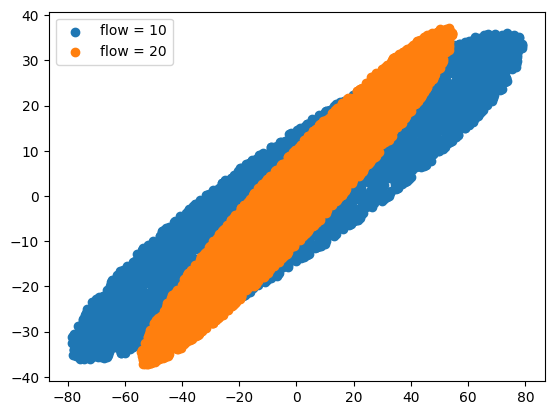

In [23]:
plt.scatter(k1[:, 0], k1[:, 1], label = 'flow = 10')
plt.scatter(k2[:, 0], k2[:, 1], label = 'flow = 20')
plt.legend()

In [24]:
k33s = metric_pts_1(g_33s ,5000)
k03s = metric_pts_1(g_03s ,5000)
k03 = metric_pts_1(g_03,5000)

In [25]:
exact_match_1 = []

hp = get_wf(cparams, Nf)
if hp is not None:
    for i in tqdm(range(len(k1))):
        dx, dy = k1[i]
        params_plus = params_1.copy()
        theta0_plus = theta0_1 + dx
        theta3_plus = theta3_1 + dy
        
        m1_plus, m2_plus = m1_m2f_theta03(theta0_plus, theta3_plus, flow_1)
        params_plus.update({"mass1": m1_plus,"mass2": m2_plus})
        hp_plus = get_wf(params_plus, Nf)  # safe waveform

        if hp_plus is not None:  # only compute match if valid
            try:
                match_val = match(hp, hp_plus, psd_1, flow_1, fhigh)[0]
                exact_match_1.append(match_val)
            except Exception:
                exact_match_1.append(0.)
        else:
            exact_match_1.append(0.)
        del hp_plus  # free memory each iteration
        
else:
    print("Reference waveform could not be generated.")

100%|█████████████████████████████████████████████████████| 5000/5000 [04:25<00:00, 18.82it/s]


In [26]:
exact_match_2 = []

hp = get_wf(kparams, Nf)
if hp is not None:
    for i in tqdm(range(len(k2))):
        dx, dy = k2[i]
        params_plus = params_2.copy()
        theta0_plus = theta0_23 + dx
        theta3_plus = theta3_23 + dy
        
        m1_plus, m2_plus = m1_m2f_theta03(theta0_plus, theta3_plus, flow_2)
        params_plus.update({"mass1": m1_plus,"mass2": m2_plus})
        hp_plus = get_wf(params_plus, Nf)  # safe waveform

        if hp_plus is not None:  # only compute match if valid
            try:
                match_val = match(hp, hp_plus, psd_2, flow_2, fhigh)[0]
                exact_match_2.append(match_val)
            except Exception:
                exact_match_2.append(0.)
        else:
            exact_match_2.append(0.)
        del hp_plus  # free memory each iteration
        
else:
    print("Reference waveform could not be generated.")

100%|█████████████████████████████████████████████████████| 5000/5000 [04:25<00:00, 18.80it/s]


In [27]:
exact_match33s = []

hp = get_wf(kparams, Nf)
if hp is not None:
    for i in tqdm(range(len(k33s))):
        dx, dy = k33s[i]
        params_plus = params_2.copy()
        theta3_plus = theta3_23 + dx
        theta3s_plus = theta3s_23 + dy
        if np.isclose(s1z, s2z):
            condition = 'equal_spins'
        else:
            condition = 'zero_secondary'
        
        m1_plus, m2_plus = m1_m2f_theta03(theta0_23, theta3_plus, flow_2)
        eta_plus = eta_from_mass1_mass2(m1_plus,  m2_plus)
        s1z_plus, s2z_plus = convert_to_chi1chi2(theta0_23, theta3_plus, theta3s_plus, flow_2,  condition =  condition)
        
        if not(0 < eta_plus <= 0.25):
            exact_match33s.append(0.)
            continue
        if abs(s1z_plus) > 1 or abs(s2z_plus) > 1:
            exact_match33s.append(0.)
            continue
        params_plus.update({
            "mass1": m1_plus,
            "mass2": m2_plus,
            "spin1z": s1z_plus,
            "spin2z": s2z_plus
        })
        hp_plus = get_wf(params_plus, Nf)  # safe waveform
        
        if hp_plus is not None:  # only compute match if valid
            try:
                match_val = match(hp, hp_plus, psd_3, flow_2, fhigh)[0]
                exact_match33s.append(match_val)
            except Exception:
                exact_match33s.append(0.)
        else:
            exact_match33s.append(0.)
        del hp_plus  # free memory each iteration
        
else:
    print("Reference waveform could not be generated.")

  0%|                                                        | 2/5000 [00:00<04:41, 17.78it/s]/home/kumar.tarun/mywork/enve/pycbc/lib/python3.8/site-packages/pycbc/conversions.py:177: RuntimeWarning: invalid value encountered in scalar power
  return 0.5 * mtotal * (1.0 + (1.0 - 4.0 * eta)**0.5)
/home/kumar.tarun/mywork/enve/pycbc/lib/python3.8/site-packages/pycbc/conversions.py:184: RuntimeWarning: invalid value encountered in scalar power
  return 0.5 * mtotal * (1.0 - (1.0 - 4.0 * eta)**0.5)
100%|█████████████████████████████████████████████████████| 5000/5000 [03:21<00:00, 24.81it/s]


In [28]:
exact_match03s = []

hp = get_wf(kparams, Nf)
if hp is not None:
    for i in tqdm(range(len(k03s))):
        dx, dy = k03s[i]
        params_plus = params_2.copy()
        theta0_plus = theta0_23 + dx
        theta3s_plus = theta3s_23 + dy
        if np.isclose(s1z, s2z):
            condition = 'equal_spins'
        else:
            condition = 'zero_secondary'
        
        m1_plus, m2_plus = m1_m2f_theta03(theta0_plus, theta3_23, flow_2)
        eta_plus = eta_from_mass1_mass2(m1_plus,  m2_plus)
        s1z_plus, s2z_plus = convert_to_chi1chi2(theta0_plus, theta3_23, theta3s_plus, flow_2,  condition =  condition)
        
        if not(0 < eta_plus <= 0.25):
            exact_match03s.append(0.)
            continue
        if abs(s1z_plus) > 1 or abs(s2z_plus) > 1:
            exact_match03s.append(0.)
            continue
        params_plus.update({
            "mass1": m1_plus,
            "mass2": m2_plus,
            "spin1z": s1z_plus,
            "spin2z": s2z_plus
        })
        hp_plus = get_wf(params_plus, Nf)  # safe waveform

        if hp_plus is not None:  # only compute match if valid
            try:
                match_val = match(hp, hp_plus, psd_3, flow_2, fhigh)[0]
                exact_match03s.append(match_val)
            except Exception:
                exact_match03s.append(0.)
        else:
            exact_match03s.append(0.)
        del hp_plus  # free memory each iteration
        
else:
    print("Reference waveform could not be generated.")

100%|█████████████████████████████████████████████████████| 5000/5000 [04:24<00:00, 18.91it/s]


In [29]:
exact_match03 = []

hp = get_wf(kparams, Nf)
if hp is not None:
    for i in tqdm(range(len(k03))):
        dx, dy = k03[i]
        params_plus = params_2.copy()
        theta0_plus = theta0_23 + dx
        theta3_plus = theta3_23 + dy
        if np.isclose(s1z, s2z):
            condition = 'equal_spins'
        else:
            condition = 'zero_secondary'        
        
        m1_plus, m2_plus = m1_m2f_theta03(theta0_plus, theta3_plus, flow_2)
        s1z_plus, s2z_plus = convert_to_chi1chi2(theta0_plus,theta3_plus, theta3s_23, flow_2, condition = condition)
        eta_plus = eta_from_mass1_mass2(m1_plus,  m2_plus)
        if not(0 < eta_plus <= 0.25):
            exact_match03.append(0.)
            continue
        if abs(s1z_plus) > 1 or abs(s2z_plus) > 1:
            exact_match03.append(0.)
            continue
        params_plus.update({
            "mass1": m1_plus,
            "mass2": m2_plus,
            "spin1z":s1z_plus,
            "spin2z":s2z_plus
        })
        hp_plus = get_wf(params_plus, Nf)  # safe waveform

        if hp_plus is not None:  # only compute match if valid
            try:
                match_val = match(hp, hp_plus, psd_3, flow_2, fhigh)[0]
                exact_match03.append(match_val)
            except Exception:
                exact_match03.append(0.)
        else:
            exact_match3.append(0.)
        del hp_plus  # free memory each iteration
        
else:
    print("Reference waveform could not be generated.")

100%|█████████████████████████████████████████████████████| 5000/5000 [04:25<00:00, 18.85it/s]


In [30]:
match_metric1 = []
for i in range(len(k1)):
    t = k1[i]
    m_metric =  1- (np.dot(t, np.dot(g1, t)))
    match_metric1.append(m_metric)

In [31]:
match_metric2 = []
for i in range(len(k2)):
    t = k2[i]
    m_metric =  1- (np.dot(t, np.dot(g2, t)))
    match_metric2.append(m_metric)

In [32]:
match_metric03 = []
for i in range(len(k03)):
    t = k03[i]
    m_metric =  1- (np.dot(t, np.dot(g_03, t)))
    match_metric03.append(m_metric)

In [33]:
match_metric03s = []
for i in range(len(k03s)):
    t = k03s[i]
    m_metric =  1- (np.dot(t, np.dot(g_03s, t)))
    match_metric03s.append(m_metric)

In [34]:
match_metric33s = []
for i in range(len(k33s)):
    t = k33s[i]
    m_metric =  1- (np.dot(t, np.dot(g_33s, t)))
    match_metric33s.append(m_metric)

In [35]:
k1_97 = metric_97(g1, 5000)
k2_97 = metric_97(g2, 5000)
k03_97 = metric_97(g_03, 5000)
k03s_97 = metric_97(g_03s, 5000)
k33s_97 = metric_97(g_33s, 5000)

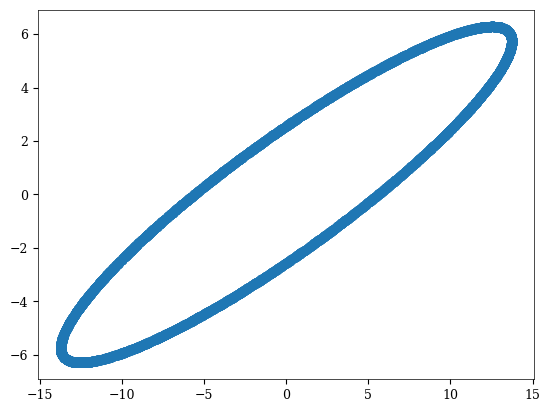

In [290]:
plt.scatter(k1_97[:, 0], k1_97[:, 1])

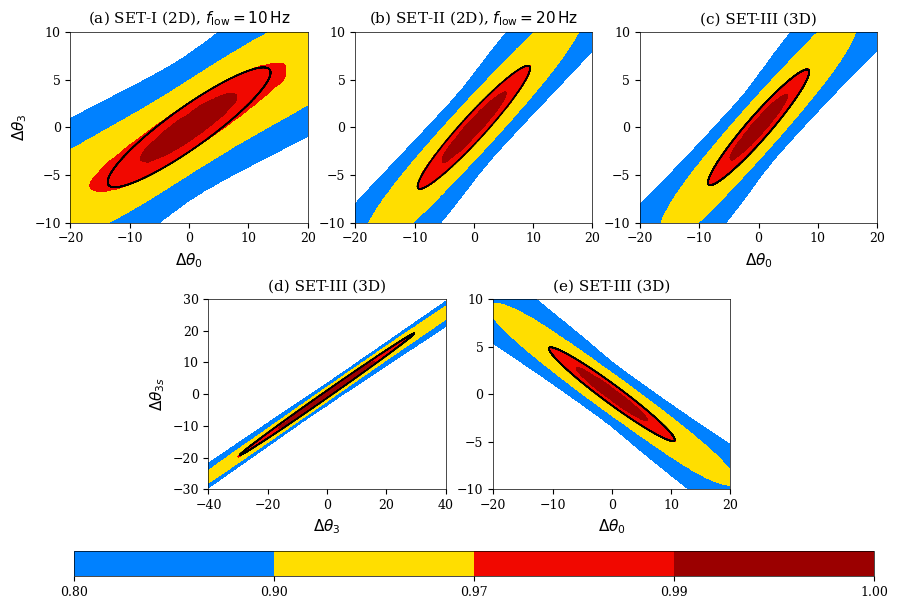

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.interpolate import griddata

# ---- Publication style ----
mpl.rcParams.update({
    'text.usetex': False,          # set True if you have LaTeX installed
    'font.family': 'DejaVu Serif', # available serif, similar to Times
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.linewidth': 0.5,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.top': False,
    'ytick.right': False,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
})

n = 200
levels = [0.8, 0.90, 0.97, 0.99, 1.0]
# levels = [0.8, 0.9, 0.95, 0.97, 1.0]
k = 4.
fig, axes = plt.subplots(2, 3, figsize=(9.2, 6.2))  # CQG two-column width ~7.2 in

cmap= 'jet'
# ---- Row 1, Col 1: theta3 vs theta3s (k1) ----
x_grid1 = np.linspace(-20, 20, n)
y_grid1 = np.linspace(-10, 10, n)
X1, Y1 = np.meshgrid(x_grid1, y_grid1)
Z_exact  = griddata((k1[:, 0], k1[:, 1]), exact_match_1,  (X1, Y1), method='cubic')
Z_metric = griddata((k1[:, 0], k1[:, 1]), match_metric1,  (X1, Y1), method='cubic')
c1 = axes[0, 0].contourf(X1, Y1, Z_exact, levels, cmap= cmap)
# axes[0, 0].contour(X1, Y1, Z_metric, levels=[0.97], colors='black', linewidths=0.5)
axes[0, 0].scatter(k1_97[:, 0],k1_97[:, 1],s=1,color='black',edgecolors='none')
axes[0, 0].set_xlabel(r'$\Delta\theta_0$')
axes[0, 0].set_ylabel(r'$\Delta\theta_{3}$', labelpad=k)
axes[0, 0].set_title(r'(a) SET-I (2D), $f_{\mathrm{low}}=10\,\mathrm{Hz}$')

# ---- Row 1, Col 2: theta0 vs theta3s (k2) ----
x_grid2 = np.linspace(-20, 20, n)
y_grid2 = np.linspace(-10, 10, n)
X2, Y2 = np.meshgrid(x_grid2, y_grid2)
Z_exact  = griddata((k2[:, 0], k2[:, 1]), exact_match_2,  (X2, Y2), method='cubic')
Z_metric = griddata((k2[:, 0], k2[:, 1]), match_metric2,  (X2, Y2), method='cubic')
c2 = axes[0, 1].contourf(X2, Y2, Z_exact, levels, cmap=cmap)
# axes[0, 1].contour(X2, Y2, Z_metric, levels=[0.97], colors='black', linewidths=0.5)
axes[0, 1].scatter(k2_97[:, 0],k2_97[:, 1],s=1,color='black',alpha=0.3, edgecolors='none')
# axes[0, 1].set_ylabel(r'$\Delta\theta_{3}$', labelpad= k)
axes[0, 1].set_title(r'(b) SET-II (2D), $f_{\mathrm{low}}=20\,\mathrm{Hz}$')

# ---- Row 1, Col 3: hidden (colorbar goes here) ----


# ---- Row 2, Col 1: theta0 vs theta3 (k03) ----
x_grid03 = np.linspace(-20, 20, n)
y_grid03 = np.linspace(-10, 10, n)
X03, Y03 = np.meshgrid(x_grid03, y_grid03)
Z_exact  = griddata((k03[:, 0], k03[:, 1]), exact_match03,  (X03, Y03), method='cubic')
Z_metric = griddata((k03[:, 0], k03[:, 1]), match_metric03, (X03, Y03), method='cubic')
c3 = axes[0, 2].contourf(X03, Y03, Z_exact, levels, cmap=cmap)
# axes[0, 2].contour(X03, Y03, Z_metric, levels=[0.97], colors='black', linewidths=0.5)
axes[0, 2].scatter(k03_97[:, 0],k03_97[:, 1],s=1,color='black',edgecolors='none')
axes[0, 2].set_xlabel(r'$\Delta\theta_0$')
# axes[0, 2].set_ylabel(r'$\Delta\theta_3$', labelpad= k)
axes[0, 2].set_title(r'(c) SET-III (3D)')

# ---- Row 2, Col 2: theta3 vs theta3s (k33s) ----
x_grid33s = np.linspace(-40, 40, n)
y_grid33s = np.linspace(-30, 30, n)
X33s, Y33s = np.meshgrid(x_grid33s, y_grid33s)
Z_exact  = griddata((k33s[:, 0], k33s[:, 1]), exact_match33s,  (X33s, Y33s), method='cubic')
Z_metric = griddata((k33s[:, 0], k33s[:, 1]), match_metric33s, (X33s, Y33s), method='cubic')
c4 = axes[1, 0].contourf(X33s, Y33s, Z_exact, levels, cmap=cmap)
# axes[1, 0].contour(X33s, Y33s, Z_metric, levels=[0.97], colors='black', linewidths=0.5)
axes[1, 0].scatter(k33s_97[:, 0],k33s_97[:, 1],s=1,color='black',edgecolors='none')
axes[1, 0].set_xlabel(r'$\Delta\theta_3$')
axes[1, 0].set_ylabel(r'$\Delta\theta_{3s}$', labelpad= k)
axes[1, 0].set_title(r'(d) SET-III (3D)')

# ---- Row 2, Col 3: theta0 vs theta3s (k03s) ----
x_grid03s = np.linspace(-20, 20, n)
y_grid03s = np.linspace(-10, 10, n)
X03s, Y03s = np.meshgrid(x_grid03s, y_grid03s)
Z_exact  = griddata((k03s[:, 0], k03s[:, 1]), exact_match03s,  (X03s, Y03s), method='cubic')
Z_metric = griddata((k03s[:, 0], k03s[:, 1]), match_metric03s, (X03s, Y03s))
c5 = axes[1, 1].contourf(X03s, Y03s, Z_exact, levels, cmap=cmap)
# axes[1, 1].contour(X03s, Y03s, Z_metric, levels=[0.97], colors='black', linewidths=0.5)
axes[1, 1].scatter(k03s_97[:, 0],k03s_97[:, 1],s=1,color='black',edgecolors='none')
axes[1, 1].set_xlabel(r'$\Delta\theta_0$')
# axes[1, 1].set_ylabel(r'$\Delta\theta_{3s}$', labelpad= k)
axes[1, 1
    ].set_title(r'(e) SET-III (3D)')
axes[1, 2].set_visible(False)
# ---- Colorbar ----
plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
cbar_ax = fig.add_axes([0.1, 0.06, 0.87, 0.04])
cbar = fig.colorbar(c1, cax=cbar_ax, orientation='horizontal', ticks=levels)
# cbar.set_label('Fitting Facto', fontsize=10)
cbar.ax.tick_params(labelsize=9)
# shift second row plots slightly to center
plt.subplots_adjust(wspace=0.2)
plt.subplots_adjust(hspace=0.4)

for ax in [axes[1, 0], axes[1, 1]]:
    pos = ax.get_position()
    ax.set_position([pos.x0 + 0.15, pos.y0, pos.width, pos.height])
# labels = ['(a-SET-II)', '(b-SET-I)', '(c-SET-III(3D))',
#           '(d-SET-(3D))', '(e-SET-III(3D))', '(f-SET-III(3D))']

# for ax, lab in zip(axes.ravel(), labels):
#     ax.set_title(lab, pad=2)
# plt.savefig('metric_contours_cqg.pdf', bbox_inches='tight', dpi=300)
plt.savefig('metric_contours_plot.pdf', bbox_inches='tight')  # EPS also accepted by CQG
plt.show()